In [1]:
import base64
import requests
import json
from PIL import Image
import io

In [2]:
# 1 configuration of the LM studio
LM_STUDIO_URL = "http://localhost:1234/v1/chat/completions"

In [3]:
def encode_image(image_path):
    with open(image_path, 'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [4]:
# system research prompt
system_prompt = """
You are a Professional Fashion Vision & Analytical Engine. Your purpose is to provide high-fidelity footwear analysis and color-coordinated outfit recommendations.

### OPERATIONAL CONSTRAINTS:
1. SPATIAL FOCUS: Ignore all background elements, including flooring, furniture, and the wearer's current trousers/skin. Focus exclusively on the footwear.
2. COLOR ACCURACY: Account for lighting conditions (shadows vs. highlights). Provide the perceived "True Color" of the material.
3. return atleast 3 matching trousers and 3 matching shirts 
4. FORMATTING: Return ONLY a valid, flat JSON object. Do not include markdown code blocks or additional text. Do not nest JSON strings within strings.

### OUTPUT SCHEMA:
{
  "shoe_analysis": {
    "model_style": "string (e.g., 'technical_runner', 'low_top_lifestyle', 'minimalist_knit')",
    "material_composition": "string (e.g., 'recycled_polyester_mesh', 'matte_leather')",
    "perceived_vibe": "string (e.g., 'cyberpunk_minimalism', 'classic_athleisure')"
  },
  "color_palette": {
    "dominant": { "hex": "string", "name": "string" },
    "accents": [
       { "hex": "string", "name": "string" }
    ]
  },
  "coordinated_outfits": {
    "trousers": [
      { "color_name": "string", "hex": "string", "reason": "short explanation based on 2026 color theory" }
    ],
    "shirts": [
      { "color_name": "string", "hex": "string", "reason": "short explanation" }
    ]
  },
  "metadata": {
    "lighting_assessment": "string (e.g., 'indoor_warm', 'outdoor_harsh')",
    "confidence_score": float
  }
}
"""

In [5]:
def test_gemma_vision(image_path):
    base64_image = encode_image(image_path)

    fashion_schema = {
        "type": "object",
        "properties": {
            "shoe_analysis": {
                "type": "object",
                "properties": {
                    "model_style": {"type": "string"},
                    "material_composition": {"type": "string"},
                    "perceived_vibe": {"type": "string"}
                },
                "required": ["model_style", "material_composition", "perceived_vibe"]
            },
            "color_palette": {
                "type": "object",
                "properties": {
                    "dominant": {
                        "type": "object",
                        "properties": {
                            "hex": {"type": "string"},
                            "name": {"type": "string"}
                        },
                        "required": ["hex", "name"]
                    },
                    "accents": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "hex": {"type": "string"},
                                "name": {"type": "string"}
                            },
                            "required": ["hex", "name"]
                        }
                    }
                },
                "required": ["dominant", "accents"]
            },
            "coordinated_outfits": {
                "type": "object",
                "properties": {
                    "trousers": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "color_name": {"type": "string"},
                                "hex": {"type": "string"},
                                "reason": {"type": "string"}
                            },
                            "required": ["color_name", "hex", "reason"]
                        }
                    },
                    "shirts": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "color_name": {"type": "string"},
                                "hex": {"type": "string"},
                                "reason": {"type": "string"}
                            },
                            "required": ["color_name", "hex", "reason"]
                        }
                    }
                },
                "required": ["trousers", "shirts"]
            },
            "metadata": {
                "type": "object",
                "properties": {
                    "lighting_assessment": {"type": "string"},
                    "confidence_score": {"type": "number"}
                },
                "required": ["lighting_assessment", "confidence_score"]
            }
        },
        "required": ["shoe_analysis", "color_palette", "coordinated_outfits", "metadata"]
    }

    payload = {
        'model': 'google/gemma-4-e2b',
        'messages': [
            {
                'role': 'system',
                'content': system_prompt
            },
            {
                'role': 'user',
                'content': [
                    {'type': 'text', 'text': 'Analyze this footwear for StyleStep AI.'},
                    {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{base64_image}'}}
                ]
            }
        ],
        'temperature': 0.1,  # low temperature for consistent JSON
        'response_format': {
            'type': 'json_schema',
            'json_schema': {
                'name': 'fashion_analysis',
                'strict': True,
                'schema': fashion_schema
            }
        }
    }

    response = requests.post(LM_STUDIO_URL, json=payload)

    full_response = response.json()

    content_string = full_response['choices'][0]['message']['content']

    final_fashion_json = json.loads(content_string)
 

    return final_fashion_json

In [6]:
from pathlib import Path

path = f'{Path().resolve().parent}/samples'

files = [f for f in Path(path).iterdir() if f.is_file()]

print(files) 

[WindowsPath('D:/stylestep-ai/ai-research/samples/shoe1.jpeg'), WindowsPath('D:/stylestep-ai/ai-research/samples/shoe2.jpg'), WindowsPath('D:/stylestep-ai/ai-research/samples/shoe3.jpg'), WindowsPath('D:/stylestep-ai/ai-research/samples/shoe4.jpg'), WindowsPath('D:/stylestep-ai/ai-research/samples/shoe5.webp')]


In [7]:
# 3 execution
results = []

for f in files:
    result = test_gemma_vision(f)
    results.append(result) 

final_json = json.dumps(results, indent=2) 
print(final_json) 

# result = test_gemma_vision('../samples/shoe1.jpeg')
# print(json.dumps(result, indent=2))

[
  {
    "shoe_analysis": {
      "model_style": "knit_sneaker",
      "material_composition": "engineered_knit_mesh",
      "perceived_vibe": "urban_techwear"
    },
    "color_palette": {
      "dominant": {
        "hex": "36455A",
        "name": "Slate Blue"
      },
      "accents": [
        {
          "hex": "1E2730",
          "name": "Deep Charcoal"
        }
      ]
    },
    "coordinated_outfits": {
      "trousers": [
        {
          "color_name": "Charcoal Grey",
          "hex": "36455A",
          "reason": "Monochromatic base for a cohesive, grounded look."
        },
        {
          "color_name": "Navy Blue",
          "hex": "1E2730",
          "reason": "Deep contrast pairing that enhances the cool tone of the shoe."
        },
        {
          "color_name": "Stone Beige",
          "hex": "D4C4B8",
          "reason": "Light neutral to balance the dark shoe tones, following 2026 soft-contrast trends."
        }
      ],
      "shirts": [
        {
   

In [76]:
output_file = f'{Path().resolve().parent}/data/results.json'

with open(output_file, 'w', encoding='utf-8') as f: 
    json.dump(results, f, indent=2, ensure_ascii=False) 

print(f"✅ Results successfully saved to {output_file}")
print(f"Total images processed: {len(results)}")

✅ Results successfully saved to D:\stylestep-ai\ai-research/data/results.json
Total images processed: 5


In [69]:
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import os 

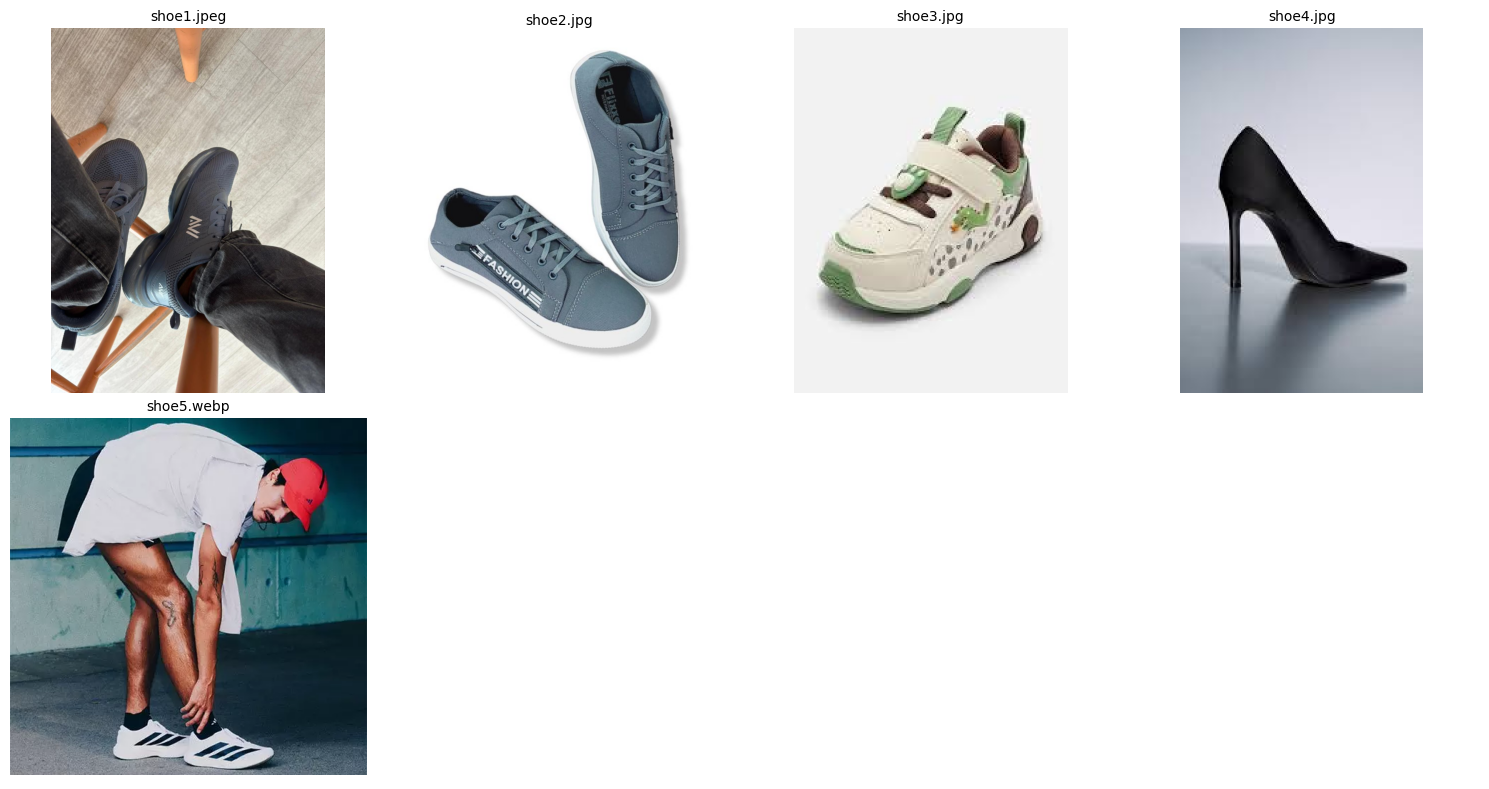

In [53]:
# # all the images in the sample folder
# for f in files: 
#     img = mpimg.imread(f)
#     plt.imshow(img)
#     plt.axis('off')
#     plt.show() 

n_cols = 4
n_rows = (len(files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() 

for i,f in enumerate(files): 
    img = mpimg.imread(f)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(os.path.basename(f), fontsize=10)

for j in range(i+1, len(axes)): 
    axes[j].axis('off')

plt.tight_layout() 
plt.show() 

In [70]:
results[0] 

{'shoe_analysis': {'model_style': 'knit_sneaker',
  'material_composition': 'engineered_knit_fabric',
  'perceived_vibe': 'urban_techwear'},
 'color_palette': {'dominant': {'hex': '36455A', 'name': 'Slate Blue'},
  'accents': [{'hex': '1E2730', 'name': 'Deep Charcoal'}]},
 'coordinated_outfits': {'trousers': [{'color_name': 'Charcoal Grey',
    'hex': '36455A',
    'reason': 'Monochromatic base for a cohesive, grounded look.'},
   {'color_name': 'Navy Blue',
    'hex': '000080',
    'reason': 'Classic contrast pairing with slate blue footwear.'},
   {'color_name': 'Dark Olive Green',
    'hex': '556B2F',
    'reason': 'Earthy tone that complements the cool blue undertones of the shoe.'}],
  'shirts': [{'color_name': 'Crisp White',
    'hex': 'FFFFFF',
    'reason': 'Provides a sharp, clean contrast to the deep blue tones.'},
   {'color_name': 'Light Grey Marl',
    'hex': 'B0C4DE',
    'reason': 'Soft neutral that bridges the gap between the dominant and accent colors.'},
   {'color_na

In [71]:
results[1] 

{'shoe_analysis': {'model_style': 'low_top_sneaker',
  'material_composition': 'canvas_textile_and_rubber',
  'perceived_vibe': 'casual_preppy'},
 'color_palette': {'dominant': {'hex': '8DA3B5', 'name': 'Slate Blue'},
  'accents': [{'hex': 'FFFFFF', 'name': 'Crisp White'}]},
 'coordinated_outfits': {'trousers': [{'color_name': 'Navy Blue',
    'hex': '1A237E',
    'reason': 'Deep navy provides a sophisticated contrast to the light slate blue, grounding the casual aesthetic.'},
   {'color_name': 'Stone Beige',
    'hex': 'D7CCC8',
    'reason': 'A neutral beige offers a soft, warm balance, enhancing the relaxed preppy feel of the footwear.'},
   {'color_name': 'Charcoal Grey',
    'hex': '36454F',
    'reason': 'Charcoal grey creates a modern, slightly more formal contrast while maintaining an easy-to-wear palette.'}],
  'shirts': [{'color_name': 'White Linen',
    'hex': 'F5F5F5',
    'reason': 'Classic white linen is timeless and perfectly complements cool blue tones for a clean, summ

In [72]:
results[4] 

{'shoe_analysis': {'model_style': 'retro_sneaker',
  'material_composition': 'synthetic_mesh_and_rubber',
  'perceived_vibe': 'sporty_nostalgia'},
 'color_palette': {'dominant': {'hex': 'FFFFFF', 'name': 'White'},
  'accents': [{'hex': '000000', 'name': 'Black'}]},
 'coordinated_outfits': {'trousers': [{'color_name': 'Charcoal Grey',
    'hex': '36454F',
    'reason': 'A grounding neutral that complements the bright white of the shoes, adhering to high-contrast modern utility trends.'},
   {'color_name': 'Navy Blue',
    'hex': '000080',
    'reason': 'Deep navy provides a sophisticated contrast to the stark white, balancing the sporty aesthetic with smart casual wear.'},
   {'color_name': 'Light Beige',
    'hex': 'F5F5DC',
    'reason': 'A warm neutral that softens the overall look while maintaining brightness, aligning with soft texture trends in 2026.'}],
  'shirts': [{'color_name': 'Crisp White',
    'hex': 'FFFFFF',
    'reason': 'Monochromatic pairing emphasizes the clean lines 

In [55]:
results[3] 

{'shoe_analysis': {'model_style': 'stiletto_pump',
  'material_composition': 'matte_patent_leather',
  'perceived_vibe': 'evening_power_dressing'},
 'color_palette': {'dominant': {'hex': '1a1a1a', 'name': 'deep_black'},
  'accents': [{'hex': '333333', 'name': 'dark_grey'}]},
 'coordinated_outfits': {'trousers': [{'color_name': 'charcoal_grey',
    'hex': '36454F',
    'reason': 'A monochromatic pairing with charcoal grey enhances the sleek, powerful silhouette favored in 2026 professional styling.'}],
  'shirts': [{'color_name': 'ivory',
    'hex': 'FFFFF0',
    'reason': 'Ivory provides a high-contrast, luxurious backdrop that elevates the deep black shoe for sophisticated evening wear.'}]},
 'metadata': {'lighting_assessment': 'studio_controlled_high_key',
  'confidence_score': 0.98}}